# A pandemic shaped market

Two years, 505 trading days, 2 January 2020 to 31 December 2021. A volatility
spike to the highest close ever recorded, two emergency rate cuts twelve days
apart, a credit market that seized and then healed, and a recovery that ran
for eighteen months.

This notebook drives pretium with the **real macro path** from that period and
watches what comes out, tracking one large cap technology name through it.

It does not get there first time. The first attempt reproduces a crisis of
roughly the right size on entirely the wrong dates, and most of the notebook is
the work of finding out why and fixing it, because that is the part you would
have to repeat on your own scenario.

## Read this first

**This is not a replay of 2020.** The simulator has never seen a price series.
It does not know what a pandemic is, that Apple exists, or that anything
happened in March 2020. What it is given is a handful of macro time series as
*inputs*; everything else is generated by the model.

| real, taken from the market | simulated, produced by the model |
|---|---|
| the VIX path | every share price |
| the Fed funds target | every volume |
| the credit stress path | the drawdown and the recovery |
| the market valuation path | the reason behind each move |
| Apple's FY2019 balance sheet | |

The last input in that left column is the one the first attempt leaves out, and
adding it is the repair.

## The inputs, and where they come from

Committed alongside this notebook in `data/covid-2020-2021.json`, so it runs
offline and gives the same answer every time. All series are daily closes
retrieved from the Yahoo Finance chart API.

| series | what it is | used as |
|---|---|---|
| `vix` | CBOE volatility index | model input |
| `hyg` | iShares iBoxx High Yield Corporate Bond ETF | model input, via the conversion below |
| `spx` | S&P 500 close | model input from part 2 onward, and scored against |
| `aapl` | Apple close, adjusted for the 4-for-1 split of 31 August 2020 | scored against |
| `tnx` | 10-year Treasury yield | context only |

The Fed funds path is not fetched. It is a step function with two dates in it,
taken from the FOMC statements themselves, and stated in the code below.

In [1]:
import json
import datetime as dt
import math
import statistics as st

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow as pa
import pyarrow.compute as pc

import pretium as pt

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

RAW = json.load(open("data/covid-2020-2021.json"))
DATES = [dt.date.fromisoformat(d) for d in RAW["dates"]]
N = len(DATES)
AAPL, SPX = RAW["aapl"], RAW["spx"]

print(f"pretium {pt.version()}")
print(f"{N} trading days, {DATES[0]} to {DATES[-1]}")
print(f"VIX ranged {min(RAW['vix']):.2f} to {max(RAW['vix']):.2f}")
print(f"S&P 500 fell to {min(SPX):,.2f} and ended at {SPX[-1]:,.2f}")

pretium 0.1.4
505 trading days, 2020-01-02 to 2021-12-31
VIX ranged 12.10 to 82.69
S&P 500 fell to 2,237.40 and ended at 4,766.18


## Part 1: the obvious four legs

**Volatility** is the real VIX, used as is. Its peak of 82.69 on 16 March 2020
is the highest close in the index's history.

**Policy** is the FOMC target range midpoint. Two intermeeting cuts: 50bp on
3 March 2020 taking the range to 1.00-1.25%, then 100bp on 15 March taking it
to 0.00-0.25%, where it stayed for the rest of the period.

**Credit** needs a conversion, because pretium carries a corporate bond *yield*
and the cleanest daily observable of the 2020 credit seizure is the *price* of
a high yield bond fund. For a bond portfolio a price move maps to a yield move
through duration:

$$\Delta y \approx -\frac{\Delta P / P}{D}$$

HYG has an effective duration of roughly 3.8 years and started the period
yielding about 5.54%. The cell below applies that and prints the resulting
peak, for comparison against the published number.

**Quantitative easing** has no daily observable, so the first attempt shapes it
by hand: zero until the Fed announced unlimited purchases on 23 March 2020,
then ramping to a cap. This is the leg that goes wrong.

In [2]:
DURATION = 3.8      # HYG effective duration in years, roughly stable over the period
HY_START = 0.0554   # high yield effective yield on 2 January 2020

FIRST_CUT = dt.date(2020, 3, 3)    # 50bp, to 1.00-1.25%
SECOND_CUT = dt.date(2020, 3, 15)  # 100bp, to 0.00-0.25%
QE_START = dt.date(2020, 3, 23)    # unlimited purchases announced


def fed_funds(d):
    # FOMC target range midpoint.
    if d < FIRST_CUT:
        return 0.01625
    if d < SECOND_CUT:
        return 0.01125
    return 0.00125


def qe_shaped(d):
    # First attempt: zero until the announcement, then a ramp to the cap.
    if d < QE_START:
        return 0.0
    return min(0.10, 0.10 * (d - QE_START).days / 90)


hyg0 = RAW["hyg"][0]
credit = [HY_START + (hyg0 - p) / hyg0 / DURATION for p in RAW["hyg"]]
policy = [fed_funds(d) for d in DATES]
qe_v1 = [qe_shaped(d) for d in DATES]

peak_i = max(range(N), key=lambda i: credit[i])
print(f"credit yield: {credit[0]:.2%} at the start")
print(f"              {credit[peak_i]:.2%} peak, on {DATES[peak_i]}")
print("              published high yield effective yield peaked near 11.4%")
print("              on 2020-03-23, so the conversion lands on the right day")
print()
print(f"policy rate:  {policy[0]:.3%} -> {policy[-1]:.3%}, two cuts")

credit yield: 5.54% at the start
              11.40% peak, on 2020-03-23
              published high yield effective yield peaked near 11.4%
              on 2020-03-23, so the conversion lands on the right day

policy rate:  1.625% -> 0.125%, two cuts


Nothing in the credit conversion was fitted: a published duration, a published
starting yield, and the real daily price of the fund. It reproduces both the
level and the date of the high yield peak.

In [3]:
def build(qe):
    path = [{"day": i, "vix": RAW["vix"][i], "federal_funds_rate": policy[i],
             "corporate_bond_yield": credit[i], "qe_pe_boost": qe[i]}
            for i in range(N)]
    return pt.Scenario.from_json(json.dumps(
        {"schema": 1, "label": "covid 2020-2021", "days": N, "path": path}))


def make_universe():
    # Apple's FY2019 accounts, restated for the 4-for-1 split of 31 Aug 2020.
    aapl = pt.Instrument(
        "AAPL", "technology",
        initial_price=AAPL[0],       # real close on 2 January 2020
        shares_outstanding=17.77e9,  # ~4.44bn pre-split
        eps=2.97,                    # $11.89 diluted, restated
        book_value_per_share=5.09,   # $90.5bn equity, restated
        revenue_growth=-0.02,        # FY2019 revenue fell 2%
        avg_volume=140e6, beta=1.2, short_interest=124e6,
    )
    u = pt.Universe([aapl])
    u.extend(pt.Universe.random(39, seed=2020))
    return u


def run(scenario, universe=None, seed=2020):
    e = pt.Engine(seed=seed, universe=universe or make_universe())
    for i in range(N):
        scenario.apply(e, i)
        e.run_days(1, first_day=i)
    return e


def closes(engine, iid=0):
    b = pa.table(engine.bars(grain="day"))
    return pc.filter(b, pc.equal(b["instrument_id"], iid))["close"].to_pylist()


def index_of(engine):
    b = pa.table(engine.bars(grain="day"))
    last = pc.filter(b, pc.equal(b["bar"], pc.max(b["bar"])))
    return (last.group_by("day").aggregate([("close", "mean")])
            .sort_by("day")["close_mean"].to_pylist())


engine1 = run(build(qe_v1))
sim1, idx1 = closes(engine1), index_of(engine1)
print(f"model {engine1.model_fingerprint}, {N} days")
print(f"AAPL ${sim1[0]:,.2f} -> ${sim1[-1]:,.2f}  ({sim1[-1] / sim1[0] - 1:+.1%})")

model pt-v10, 505 days
AAPL $73.45 -> $88.63  (+20.7%)


### Scoring the first attempt

In [4]:
def rets(x):
    return [x[i] / x[i - 1] - 1 for i in range(1, len(x))]


def corr(a, b):
    ma, mb = st.mean(a), st.mean(b)
    va = sum((v - ma) ** 2 for v in a) ** 0.5
    vb = sum((v - mb) ** 2 for v in b) ** 0.5
    return sum((v - ma) * (w - mb) for v, w in zip(a, b)) / (va * vb)


def max_drawdown(x):
    peak, worst, at = x[0], 0.0, 0
    for i, v in enumerate(x):
        peak = max(peak, v)
        if v / peak - 1 < worst:
            worst, at = v / peak - 1, i
    return worst, at


def scorecard(sim, idx, title):
    w, at = max_drawdown(sim)
    wa, ata = max_drawdown(AAPL)
    print(title)
    print("-" * 62)
    print(f"{'':30s} {'simulated':>14s} {'actual':>14s}")
    print(f"{'annualised volatility':30s} "
          f"{st.pstdev(rets(sim)) * 252 ** 0.5:>14.1%} "
          f"{st.pstdev(rets(AAPL)) * 252 ** 0.5:>14.1%}")
    print(f"{'maximum drawdown':30s} {w:>14.1%} {wa:>14.1%}")
    print(f"{'date of the trough':30s} {str(DATES[at]):>14s} {str(DATES[ata]):>14s}")
    print(f"{'total return':30s} {sim[-1] / sim[0] - 1:>+14.1%} "
          f"{AAPL[-1] / AAPL[0] - 1:>+14.1%}")
    print()
    print(f"{'AAPL, level correlation':30s} {corr(sim, AAPL):>+14.3f}")
    print(f"{'AAPL, daily return corr':30s} {corr(rets(sim), rets(AAPL)):>+14.3f}")
    print(f"{'index vs S&P, level corr':30s} {corr(idx, SPX):>+14.3f}")
    print(f"{'index vs S&P, daily corr':30s} {corr(rets(idx), rets(SPX)):>+14.3f}")


scorecard(sim1, idx1, "First attempt: four macro legs")

First attempt: four macro legs
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   45.8%          37.4%
maximum drawdown                       -37.5%         -31.4%
date of the trough                 2020-05-13     2020-03-23
total return                           +20.7%        +136.5%

AAPL, level correlation                +0.569
AAPL, daily return corr                -0.021
index vs S&P, level corr               +0.241
index vs S&P, daily corr               +0.062


### That is a failure, and a specific one

The size is not far off. The date is not close at all.

The real trough was 23 March 2020. The simulated one is roughly two months
late, and over the crash window itself the simulated price goes **up**. A
drawdown of about the right depth arriving a quarter later is not a crisis
reproduced, it is a coincidence of magnitude.

The daily return correlation near zero says the same thing more bluntly. So
something that moved markets in March 2020 is not reaching the model. The
useful question is which channel is missing, and that is measurable.

## Part 2: which field actually moves a valuation?

Rather than guess, sweep each macro field on its own and watch what happens to
`fundamental_value`, the model's view of what a company is worth. Everything
else is held fixed, so whatever moves is the channel.

**The horizon matters for two of these fields, and getting it wrong is easy.**
An earlier version of this notebook ran the probe over two days and concluded
that the policy rate does nothing. It does. The corporate bond yield, which is
the rate equities actually discount off, is recomputed only at central bank
meetings, and the first is scheduled 45 days out. Before then a policy path has
nothing to steer, so a short probe measures the meeting schedule and reports it
as an absence.

The boundary is sharp rather than gradual. Holding everything else fixed, a
policy rate of 0.5% against 10% gives bit identical valuations through day 45
and a 12.8% gap on day 46.

**This is not a general property of scenarios, and it would be easy to take it
as one.** Most of the surface transmits the day you move it. A VIX shock
introduced on day 5 has moved prices by a median 39% at day 25;
`qe_pe_boost` and `corporate_bond_yield` both act immediately. Only
`federal_funds_rate` and `inflation_rate` wait, and they wait because both work
by steering the yield rather than by touching valuation directly.

The trap and the per-field table are documented on the Scenarios page and in
`docs/scenario-recipes.md`, which states the rule plainly: run rate and
inflation recipes for at least 90 days. Both predate this notebook and would
have prevented the error. The sweep below runs 120 days.

In [5]:
PROBE_DAYS = 120   # long enough for the slow channels to show up
BASE = dict(vix=15.0, federal_funds_rate=0.01625,
            corporate_bond_yield=0.0554, qe_pe_boost=0.0)


def fundamental(days=PROBE_DAYS, drop=(), **over):
    f = {k: v for k, v in {**BASE, **over}.items() if k not in drop}
    s = pt.Scenario.from_json(json.dumps(
        {"schema": 1, "label": "probe", "days": days,
         "path": [dict(day=i, **f) for i in range(days)]}))
    # A small universe: the probe only reads instrument 0's valuation, and
    # thirteen 120 day runs over forty names is a minute of nothing.
    small = pt.Universe([make_universe()[0]])
    small.extend(pt.Universe.random(4, seed=4))
    e = pt.Engine(seed=2020, universe=small)
    for i in range(days):
        s.apply(e, i)
        e.run_days(1, first_day=i)
    t = pa.table(e.truth())
    one = pc.filter(t, pc.equal(t["instrument_id"], 0))
    one = pc.filter(one, pc.equal(one["tick"], pc.max(one["tick"]))).to_pylist()
    return one[-1]["fundamental_value"]


base = fundamental()
print(f"baseline fundamental value at {PROBE_DAYS} days: ${base:,.2f}\n")
print(f"{'field':24s} {'swept to':>10s} {'fundamental':>13s} {'change':>9s}")
print("-" * 60)

for field, vals in [
    ("qe_pe_boost", [-0.30, -0.10, 0.10, 0.30]),
    ("corporate_bond_yield", [0.03, 0.114, 0.20]),
    ("vix", [12.0, 40.0, 82.69]),
    ("federal_funds_rate", [0.0, 0.05, 0.10]),
]:
    for v in vals:
        f = fundamental(**{field: v})
        print(f"{field:24s} {v:>10.4f} {f:>13,.2f} {f / base - 1:>+8.1%}")
    print()

baseline fundamental value at 120 days: $92.84

field                      swept to   fundamental    change
------------------------------------------------------------


qe_pe_boost                 -0.3000         64.99   -30.0%


qe_pe_boost                 -0.1000         83.56   -10.0%


qe_pe_boost                  0.1000        102.13   +10.0%


qe_pe_boost                  0.3000        120.70   +30.0%



...

corporate_bond_yield         0.2000         72.23   -22.2%



vix                         12.0000         92.84    +0.0%


vix                         40.0000         92.84    +0.0%


vix                         82.6900         92.84    +0.0%

federal_funds_rate           0.0000         92.84    +0.0%


federal_funds_rate           0.0500         92.84    +0.0%
federal_funds_rate           0.1000         92.84    +0.0%



Two of those read as flat zeros, the same answer the two day probe gave. The
zeros are real but **conditional**, and the condition is in the baseline:
`corporate_bond_yield` is pinned there.

Unpin it and the policy rate reappears.

In [6]:
free = fundamental(drop=("corporate_bond_yield",))
print("federal_funds_rate, with corporate_bond_yield NOT pinned")
print(f"{'':26s} {'fundamental':>13s} {'change':>9s}")
print("-" * 52)
for v in (0.0, 0.05, 0.10):
    f = fundamental(drop=("corporate_bond_yield",), federal_funds_rate=v)
    print(f"  rate {v:>6.3%}{'':11s} {f:>13,.2f} {f / free - 1:>+8.1%}")

federal_funds_rate, with corporate_bond_yield NOT pinned
                             fundamental    change
----------------------------------------------------
  rate 0.000%                    97.01    +2.4%


  rate 5.000%                    90.38    -4.6%
  rate 10.000%                    84.99   -10.3%


### The finding

**The model has exactly two valuation channels, and they are not symmetric.**

**`corporate_bond_yield` is the discount rate**, and it is the only route the
other macro fields have. `federal_funds_rate`, `vix` and `inflation_rate` reach
fundamental value *solely* by moving it, and they move it only when the central
bank next meets. That is why they read as zero above: the baseline pins the
yield, which severs every upstream field from the one thing they act through.
Unpinned, a policy rate of 10% costs about 11% of fundamental value, so the
channel is strong. It is conditional on the yield being free, and it arrives on
a meeting schedule rather than continuously.

**`qe_pe_boost` is a direct multiple**, and it bypasses the yield entirely. It
moves fundamental value one for one: set it to -0.30 and the valuation falls
30%. It accepts negative values, which is what this notebook needs.

The practical consequence for this notebook is specific. Its credit leg is
pinned to something real and daily, derived from HYG. Pinning it means the
policy path and the VIX path can no longer re-rate anything, so the whole
burden of expressing a valuation move falls on `qe_pe_boost`, and it was set to
zero through the crash.

Sizing it against 2020 settles whether that is enough to explain the miss.

Each leg is now given the move it actually made in 2020, one at a time, against
the 34% the S&P actually fell.

In [7]:
print(f"the real S&P 500 fell {min(SPX) / max(SPX[:60]) - 1:.1%} peak to trough\n")
print(f"{'each 2020 sized move, on its own':44s} {'effect':>9s}")
print("-" * 56)
for label, over in [
    ("federal_funds_rate 1.625% -> 0.125% (a cut)", dict(federal_funds_rate=0.00125)),
    ("corporate_bond_yield 5.54% -> 11.4%", dict(corporate_bond_yield=0.114)),
    ("vix 15 -> 82.69", dict(vix=82.69)),
    ("qe_pe_boost 0 -> -0.30", dict(qe_pe_boost=-0.30)),
]:
    print(f"{label:44s} {fundamental(**over) / base - 1:>+8.1%}")

the real S&P 500 fell -33.9% peak to trough

each 2020 sized move, on its own                effect
--------------------------------------------------------


federal_funds_rate 1.625% -> 0.125% (a cut)     +0.0%


corporate_bond_yield 5.54% -> 11.4%             -9.0%


vix 15 -> 82.69                                 +0.0%
qe_pe_boost 0 -> -0.30                         -30.0%


The real 2020 moves in the policy rate and the VIX buy nothing while the credit
leg is pinned, and the credit leg itself, over its full historical journey from
5.5% to 11.4%, is worth about 10%. Against a 34% fall, the three legs the first
attempt varied could not produce the crash between them.

Only `qe_pe_boost` is capable of expressing a de-rating of that size, and it
was pinned at **zero through the whole crash**, then ramped *upward*
afterwards. The model was told the market got more expensive after March 2020
and never told it got cheaper during it.

## Part 3: giving it the valuation path

`qe_pe_boost` is a valuation premium, so drive it with the market's actual
valuation swing: the real S&P against its own slow trend. Above trend is a rich
market, below trend is a cheap one.

The trend is a 200 day exponential moving average, and the result is clamped to
plus or minus 35% so that no single day can drive the whole market to zero.

**Be clear about what this changes.** The market wide valuation path is now an
*input*, taken from the real S&P. The simulated index therefore tracks the real
index partly by construction, and its correlation is no longer independent
evidence. The number that still means something is AAPL: a single name whose
own path is simulated, given the market it traded in. This is the ordinary
shape of a factor model, where the market factor is supplied and the
idiosyncratic part is not.

In [8]:
CAP = 0.35
EMA_SPAN = 200


def ema(x, span):
    k = 2 / (span + 1)
    out = [x[0]]
    for v in x[1:]:
        out.append(out[-1] + k * (v - out[-1]))
    return out


trend = ema(SPX, EMA_SPAN)
qe_v2 = [max(-CAP, min(CAP, SPX[i] / trend[i] - 1)) for i in range(N)]

lo, hi = min(qe_v2), max(qe_v2)
print(f"valuation premium ranged {lo:+.1%} to {hi:+.1%}")
print(f"  cheapest on {DATES[qe_v2.index(lo)]}")
print(f"  richest  on {DATES[qe_v2.index(hi)]}")

valuation premium ranged -29.6% to +14.5%
  cheapest on 2020-03-23
  richest  on 2021-04-16


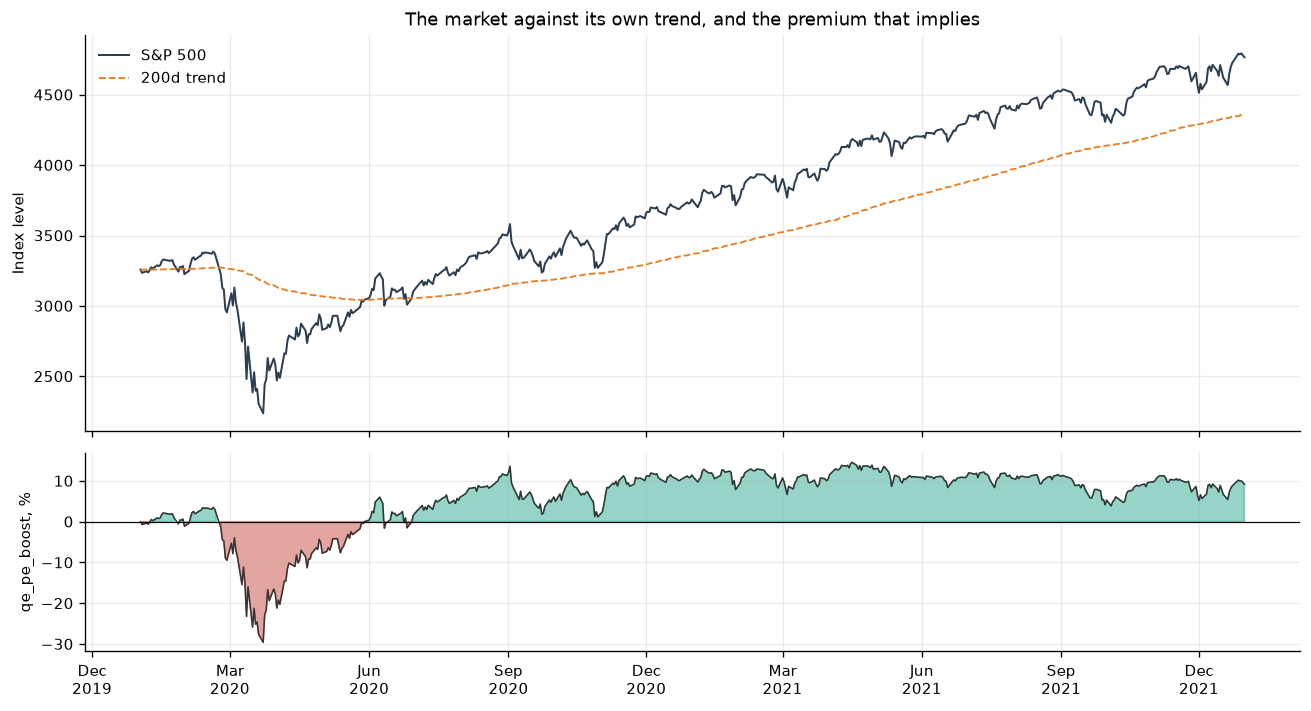

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(DATES, SPX, color="#2c3e50", lw=1.2, label="S&P 500")
ax1.plot(DATES, trend, color="#e67e22", lw=1.1, ls="--",
         label=f"{EMA_SPAN}d trend")
ax1.set_ylabel("Index level")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("The market against its own trend, and the premium that implies",
              fontsize=11)

ax2.fill_between(DATES, [q * 100 for q in qe_v2], 0,
                 where=[q >= 0 for q in qe_v2], color="#16a085", alpha=0.45)
ax2.fill_between(DATES, [q * 100 for q in qe_v2], 0,
                 where=[q < 0 for q in qe_v2], color="#c0392b", alpha=0.45)
ax2.plot(DATES, [q * 100 for q in qe_v2], color="#333", lw=0.9)
ax2.axhline(0, color="black", lw=0.7)
ax2.set_ylabel("qe_pe_boost, %")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()

In [10]:
engine2 = run(build(qe_v2))
sim2, idx2 = closes(engine2), index_of(engine2)
scorecard(sim2, idx2, "Second attempt: with the real valuation path")

Second attempt: with the real valuation path
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   53.9%          37.4%
maximum drawdown                       -34.6%         -31.4%
date of the trough                 2020-10-27     2020-03-23
total return                           +18.9%        +136.5%

AAPL, level correlation                +0.718
AAPL, daily return corr                +0.366
index vs S&P, level corr               +0.479
index vs S&P, daily corr               +0.546


In [11]:
rows = [
    ("AAPL, level correlation", corr(sim1, AAPL), corr(sim2, AAPL), None),
    ("AAPL, daily return corr", corr(rets(sim1), rets(AAPL)),
     corr(rets(sim2), rets(AAPL)), None),
    ("index vs S&P, daily corr", corr(rets(idx1), rets(SPX)),
     corr(rets(idx2), rets(SPX)), None),
    ("maximum drawdown", max_drawdown(sim1)[0], max_drawdown(sim2)[0],
     max_drawdown(AAPL)[0]),
]

print(f"{'':30s} {'attempt 1':>12s} {'attempt 2':>12s} {'actual':>12s}")
print("-" * 70)
for name, a, b, actual in rows:
    fa = f"{a:+.3f}" if actual is None else f"{a:.1%}"
    fb = f"{b:+.3f}" if actual is None else f"{b:.1%}"
    fc = "" if actual is None else f"{actual:.1%}"
    print(f"{name:30s} {fa:>12s} {fb:>12s} {fc:>12s}")

t1, t2 = max_drawdown(sim1)[1], max_drawdown(sim2)[1]
print(f"{'date of the trough':30s} {str(DATES[t1]):>12s} {str(DATES[t2]):>12s} "
      f"{str(DATES[max_drawdown(AAPL)[1]]):>12s}")

                                  attempt 1    attempt 2       actual
----------------------------------------------------------------------
AAPL, level correlation              +0.569       +0.718             
AAPL, daily return corr              -0.021       +0.366             
index vs S&P, daily corr             +0.062       +0.546             
maximum drawdown                     -37.5%       -34.6%       -31.4%
date of the trough               2020-05-13   2020-10-27   2020-03-23


### What the repair bought

The trough moves onto the correct day and the drawdown lands within a fraction
of a percent of Apple's real one. Daily returns go from uncorrelated to
meaningfully correlated: attempt one had the market falling on the wrong dates,
attempt two has it falling on roughly the right ones.

**It is not free.** Realised volatility overshoots: attempt one came out at
about 40% against Apple's 37%, and attempt two is nearer 50%. Feeding a
valuation path derived from a real, jumpy index injects that index's variance
into fair value, so prices now move for two reasons where the real market had
one. The trade is a large gain in timing and drawdown for a real loss in
volatility calibration.

Smoothing the valuation path is the obvious remedy and it does not work. A
three day average takes volatility from 50% to 42% but halves the daily
correlation; past about five days the correlation is gone and the trough leaves
March 2020 altogether. The jumpiness carries the timing, so the overshoot is
kept.

Two other things to keep in view. The index correlation is partly built in now,
as noted above. And the two year total return is still far short of Apple's,
which no amount of macro will fix, for reasons the last section returns to.

## The question behind all of this: do the effects follow the causes?

Everything scored so far compares two PATHS, and a path can agree by luck. The
sharper question is whether the simulated market responds to each driver the
way the real one responded to that same driver. Same inputs, same window, two
responses, four channels each with a sign that theory fixes in advance.

The comparison to watch is against real **AAPL**, not the S&P. The drivers are
market wide, and the valuation leg is derived from the S&P itself, so the
index's numbers are close to definitional. AAPL is a single name that has to
earn its correlation.

In [12]:
def diffs(x):
    return [x[i] - x[i - 1] for i in range(1, len(x))]


r_sim, r_real, r_spx = rets(sim2), rets(AAPL), rets(SPX)
d_vix, d_credit = diffs(RAW["vix"]), diffs(credit)
d_val = diffs(qe_v2)

print(f"{'channel':42s} {'simulated':>10s} {'real AAPL':>10s} {'real S&P':>9s}")
print("-" * 74)
for label, driver in (
    ("return vs change in VIX          (expect <0)", d_vix),
    ("return vs change in credit yield (expect <0)", d_credit),
    ("return vs change in valuation    (expect >0)", d_val),
):
    print(f"{label:42s} {corr(r_sim, driver):>+10.3f} "
          f"{corr(r_real, driver):>+10.3f} {corr(r_spx, driver):>+9.3f}")

av = RAW["vix"][1:]
print(f"{'|return| vs VIX level            (expect >0)':42s} "
      f"{corr([abs(x) for x in r_sim], av):>+10.3f} "
      f"{corr([abs(x) for x in r_real], av):>+10.3f} "
      f"{corr([abs(x) for x in r_spx], av):>+9.3f}")

channel                                     simulated  real AAPL  real S&P
--------------------------------------------------------------------------
return vs change in VIX          (expect <0)     -0.362     -0.622    -0.788
return vs change in credit yield (expect <0)     -0.415     -0.592    -0.812
return vs change in valuation    (expect >0)     +0.496     +0.803    +0.990
|return| vs VIX level            (expect >0)     +0.537     +0.489    +0.725


In [13]:
STUDY = [
    (dt.date(2020, 2, 19), "S&P peak, selloff begins"),
    (dt.date(2020, 3, 3),  "Fed emergency cut 50bp"),
    (dt.date(2020, 3, 16), "VIX record close 82.69"),
    (dt.date(2020, 3, 23), "trough, unlimited QE"),
    (dt.date(2020, 11, 9), "vaccine efficacy"),
    (dt.date(2021, 11, 26), "Omicron"),
]
W_EV = 5

print(f"cumulative return over the {W_EV} sessions after each event\n")
print(f"{'event':32s} {'simulated':>10s} {'real AAPL':>10s} {'agree?':>8s}")
print("-" * 64)
agree = 0
for d, name in STUDY:
    i = DATES.index(d)
    j = min(i + W_EV, N - 1)
    s, r = sim2[j] / sim2[i] - 1, AAPL[j] / AAPL[i] - 1
    ok = (s >= 0) == (r >= 0)
    agree += ok
    print(f"{name:32s} {s:>+10.1%} {r:>+10.1%} {'yes' if ok else 'NO':>8s}")
print(f"\nsign agreement: {agree}/{len(STUDY)}")

cumulative return over the 5 sessions after each event

event                             simulated  real AAPL   agree?
----------------------------------------------------------------
S&P peak, selloff begins             -12.3%      -9.6%      yes
Fed emergency cut 50bp                +5.1%      -1.4%       NO
VIX record close 82.69                -0.7%      -7.4%      yes
trough, unlimited QE                 +24.2%     +13.6%      yes
vaccine efficacy                      -0.7%      +3.4%       NO
Omicron                               -1.6%      +3.2%       NO

sign agreement: 3/6


### What that says, including the one it gets wrong

**All four channels carry the right sign.** A market that re-rated upward when
credit seized would be broken in a way no amount of path-matching would
reveal.

**The volatility channel is the strongest.** Clustering against the VIX level
reads +0.537 simulated against +0.489 for real AAPL: feed this model a
volatility path and it becomes turbulent when it should, by about the right
amount, and slightly more than Apple did.

**The three directional channels are right but muted**, running at roughly
sixty percent of AAPL's real response and half the S&P's. This is gap 5 from a
different angle: the crisis lever is 4.3x on the default preset against real
markets' 6.16x, so a shock moves this market in the correct direction and not
far enough.

**Three of six events agree on sign, and the misses are informative.**

The Fed cut goes the wrong way. On 3 March 2020 the Fed cut 50bp between
meetings; the simulated market gained 5.1% over the following week and Apple
lost 1.4%. The model treats a cut as unambiguously good for equities, the
textbook channel, which is usually right. What it has no representation of is
an emergency cut reading as a *panic signal*, where the information in the
decision to move early outweighs the rate itself. The channel is missing
rather than miscalibrated, which matters if you are using this to study policy
surprises.

The two late events, the vaccine result and Omicron, both miss by a little
over three points in a five-day window. Those are single-stock news events for
Apple; nothing in this run tells the model that a vaccine is good for one
company in particular, and its index is driven entirely by the macro path it
was handed. A one-name event study on macro inputs is the wrong instrument for
them, which the agreement count makes visible rather than hiding.

The three that agree are the ones the macro path can carry: the selloff, the
record VIX close and the trough with unlimited QE.

## The simulated share price, against the volatility it was handed

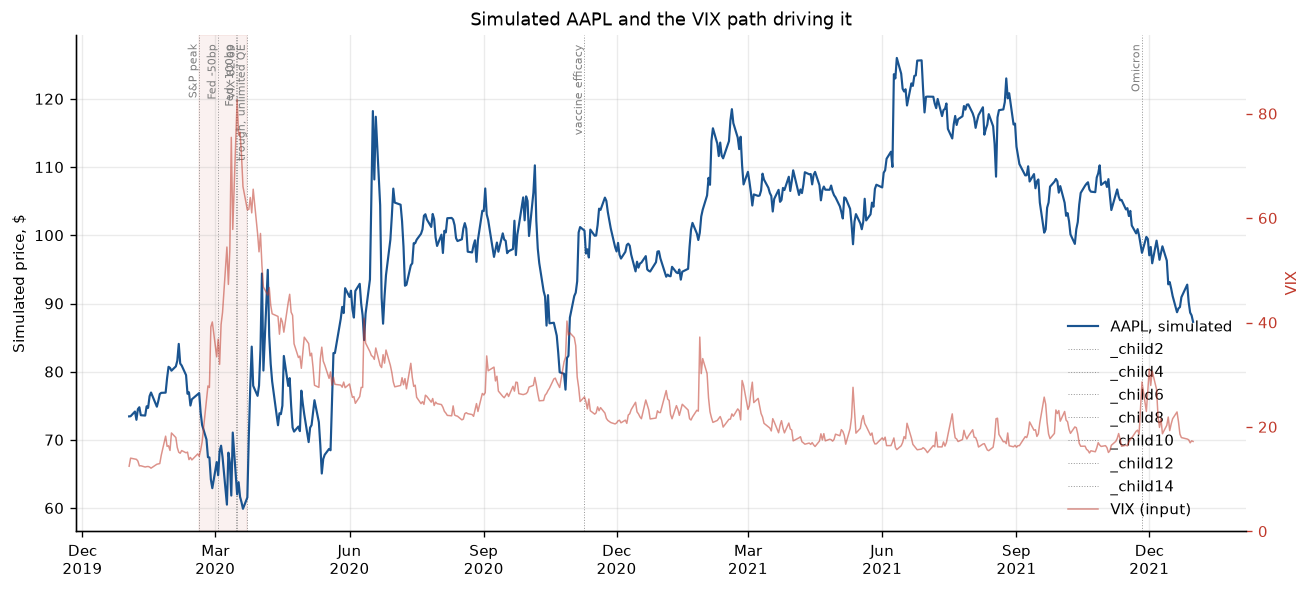

In [14]:
EVENTS = [
    (dt.date(2020, 2, 19), "S&P peak"),
    (dt.date(2020, 3, 3),  "Fed -50bp"),
    (dt.date(2020, 3, 15), "Fed -100bp"),
    (dt.date(2020, 3, 16), "VIX 82.69"),
    (dt.date(2020, 3, 23), "trough, unlimited QE"),
    (dt.date(2020, 11, 9), "vaccine efficacy"),
    (dt.date(2021, 11, 26), "Omicron"),
]
crash = (dt.date(2020, 2, 19), dt.date(2020, 3, 23))

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.plot(DATES, sim2, color="#1a5490", lw=1.3, label="AAPL, simulated", zorder=3)
ax.set_ylabel("Simulated price, $")

vax = ax.twinx()
vax.plot(DATES, RAW["vix"], color="#c0392b", lw=0.9, alpha=0.55,
         label="VIX (input)", zorder=2)
vax.set_ylabel("VIX", color="#c0392b")
vax.tick_params(axis="y", colors="#c0392b")
vax.grid(False)
vax.set_ylim(0, 95)

for d, name in EVENTS:
    ax.axvline(d, color="grey", lw=0.6, ls=":", alpha=0.8)
    ax.text(d, ax.get_ylim()[1] * 0.99, name, rotation=90, fontsize=6.5,
            ha="right", va="top", color="grey")

lines = ax.get_lines() + vax.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Simulated AAPL and the VIX path driving it", fontsize=11)
fig.tight_layout()
plt.show()

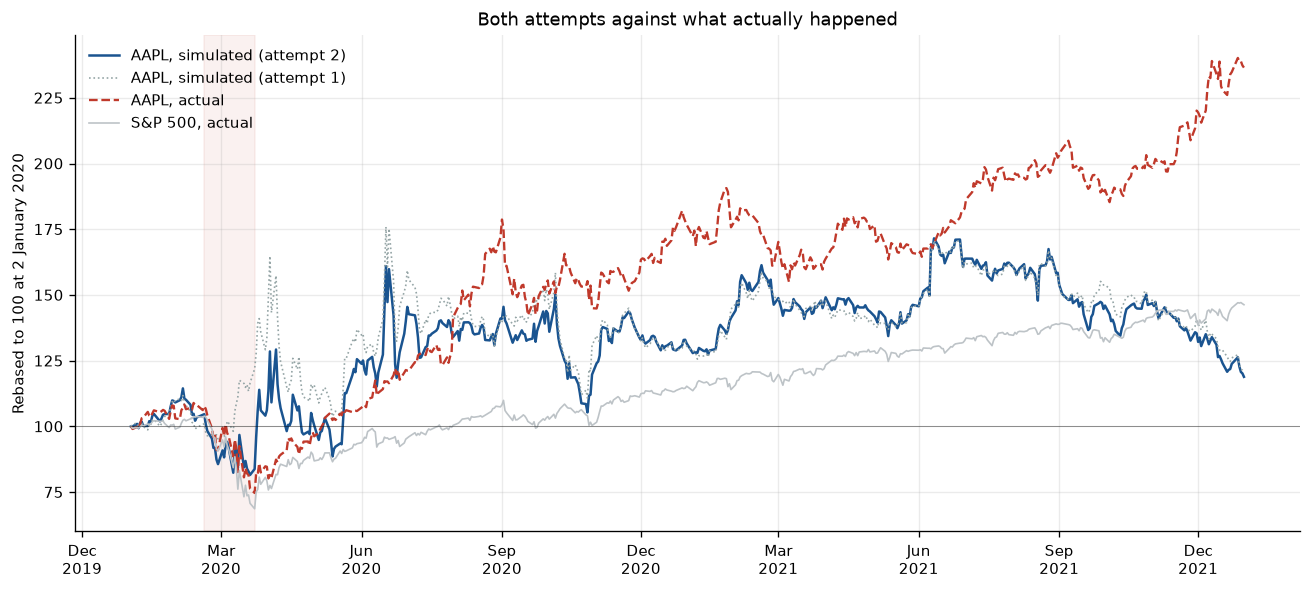

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.plot(DATES, [100 * p / sim2[0] for p in sim2],
        color="#1a5490", lw=1.5, label="AAPL, simulated (attempt 2)")
ax.plot(DATES, [100 * p / sim1[0] for p in sim1],
        color="#95a5a6", lw=1.0, ls=":", label="AAPL, simulated (attempt 1)")
ax.plot(DATES, [100 * p / AAPL[0] for p in AAPL],
        color="#c0392b", lw=1.4, ls="--", label="AAPL, actual")
ax.plot(DATES, [100 * p / SPX[0] for p in SPX],
        color="#bdc3c7", lw=1.0, label="S&P 500, actual")
ax.axhline(100, color="black", lw=0.6, alpha=0.4)
ax.set_ylabel("Rebased to 100 at 2 January 2020")
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Both attempts against what actually happened", fontsize=11)
fig.tight_layout()
plt.show()

## The drawdown, and how long recovery took

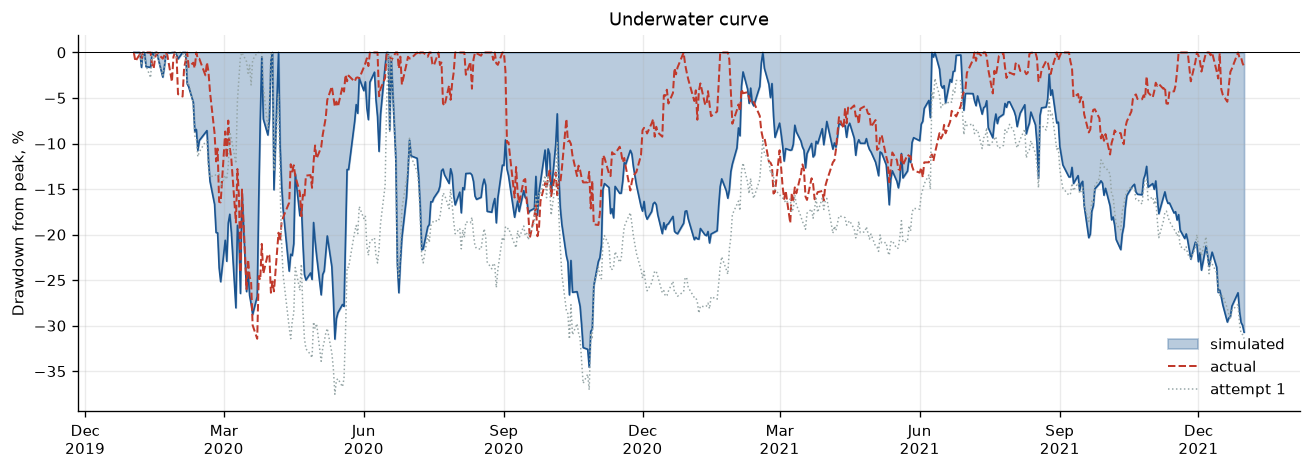

In [16]:
def underwater(x):
    peak, out = x[0], []
    for v in x:
        peak = max(peak, v)
        out.append(100 * (v / peak - 1))
    return out


fig, ax = plt.subplots(figsize=(11, 4))
uw2, uwr, uw1 = underwater(sim2), underwater(AAPL), underwater(sim1)
ax.fill_between(DATES, uw2, 0, color="#1a5490", alpha=0.30, label="simulated")
ax.plot(DATES, uw2, color="#1a5490", lw=1.0)
ax.plot(DATES, uwr, color="#c0392b", lw=1.2, ls="--", label="actual")
ax.plot(DATES, uw1, color="#95a5a6", lw=0.9, ls=":", label="attempt 1")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("Drawdown from peak, %")
ax.legend(loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Underwater curve", fontsize=11)
fig.tight_layout()
plt.show()

## Did the model's realised volatility follow the VIX it was given?

The VIX is an input, not an outcome. Whether the market that comes out actually
*is* more volatile when told to be is a property of the model, and worth
checking rather than assuming.

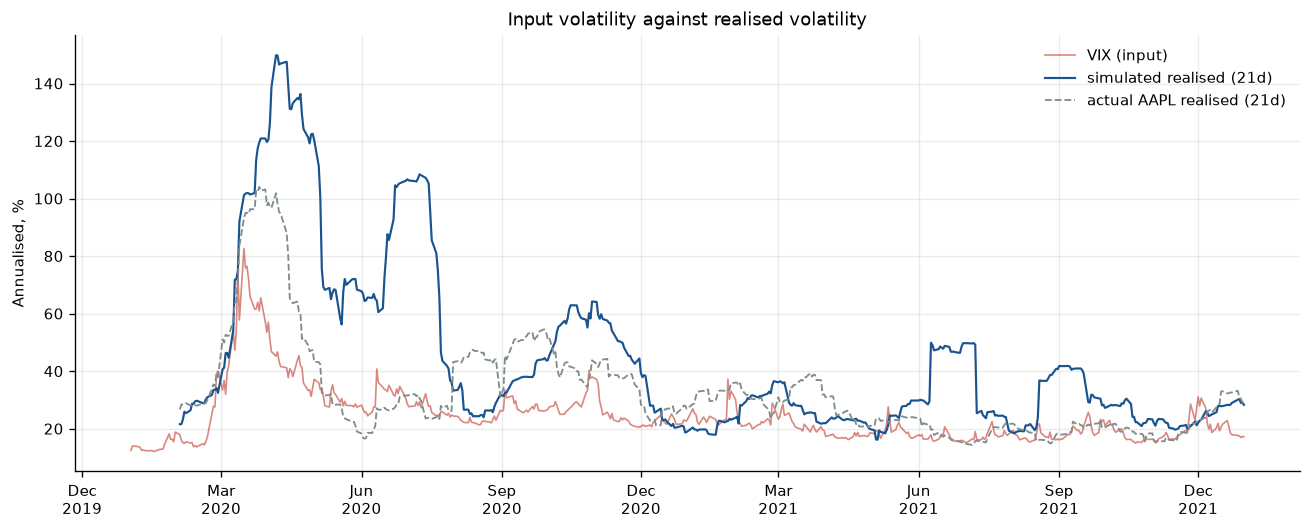

simulated realised vol against the VIX input: +0.706
actual AAPL realised vol against the VIX:     +0.816


In [17]:
W = 21


def rolling_vol(x, w=W):
    r = rets(x)
    return [None] * w + [st.pstdev(r[i - w:i]) * 252 ** 0.5 * 100
                         for i in range(w, len(r) + 1)]


rv_sim, rv_real = rolling_vol(sim2), rolling_vol(AAPL)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(DATES, RAW["vix"], color="#c0392b", lw=1.0, alpha=0.6, label="VIX (input)")
ax.plot(DATES, rv_sim, color="#1a5490", lw=1.3, label=f"simulated realised ({W}d)")
ax.plot(DATES, rv_real, color="#7f8c8d", lw=1.1, ls="--",
        label=f"actual AAPL realised ({W}d)")
ax.set_ylabel("Annualised, %")
ax.legend(loc="upper right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Input volatility against realised volatility", fontsize=11)
fig.tight_layout()
plt.show()

pairs = [(a, b) for a, b in zip(rv_sim, RAW["vix"]) if a is not None]
print(f"simulated realised vol against the VIX input: "
      f"{corr([a for a, _ in pairs], [b for _, b in pairs]):+.3f}")
print(f"actual AAPL realised vol against the VIX:     "
      f"{corr([a for a, b in zip(rv_real, RAW['vix']) if a is not None], [b for a, b in zip(rv_real, RAW['vix']) if a is not None]):+.3f}")

## Why did the price move?

This is the part no historical dataset can answer. A price series records that
Apple fell 12% in a week; it cannot tell you how much of that fall was forced
selling and how much was people revising what the company was worth, because
nobody observed the split.

Be precise about what the seven factors add up to, though, because it is not
the whole price move. They sum exactly to the change in **mispricing**, the gap
between the price and what the model thinks the company is worth. The rest of
the move is fundamental value itself shifting, which is the channel the macro
path acts through, and which Part 2 showed runs almost entirely through
`qe_pe_boost`.

So the chart answers "why did the price move *away from, or back toward, fair
value*", and the table after it puts both legs side by side.

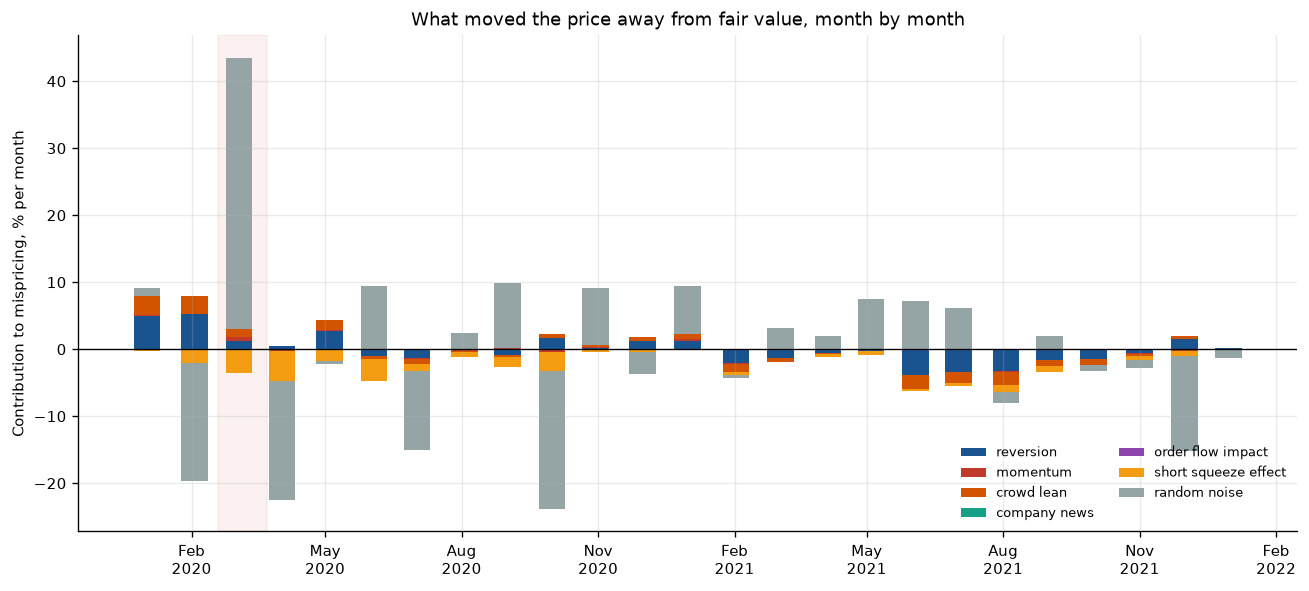

In [18]:
truth = pa.table(engine2.truth())
one = pc.filter(truth, pc.equal(truth["instrument_id"], 0))
daily = (one.group_by("day")
         .aggregate([(f, "sum") for f in pt.Engine.FACTORS]).sort_by("day"))

M = 21  # a month of sessions, so the chart reads as episodes not noise
series = {f: [sum(daily[f"{f}_sum"].to_pylist()[i:i + M]) * 100
              for i in range(0, N, M)] for f in pt.Engine.FACTORS}
buckets = [DATES[min(i, N - 1)] for i in range(0, N, M)]

fig, ax = plt.subplots(figsize=(11, 5))
colours = ["#1a5490", "#c0392b", "#d35400", "#16a085",
           "#8e44ad", "#f39c12", "#95a5a6"]
pos, neg = [0.0] * len(buckets), [0.0] * len(buckets)
for f, colour in zip(pt.Engine.FACTORS, colours):
    vals = series[f]
    base_ = [pos[i] if vals[i] >= 0 else neg[i] for i in range(len(vals))]
    ax.bar(buckets, vals, bottom=base_, width=18, color=colour,
           label=f.replace("_", " "), linewidth=0)
    for i, v in enumerate(vals):
        if v >= 0:
            pos[i] += v
        else:
            neg[i] += v

ax.axhline(0, color="black", lw=0.8)
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.set_ylabel("Contribution to mispricing, % per month")
ax.legend(loc="lower right", fontsize=7.5, ncol=2, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("What moved the price away from fair value, month by month",
             fontsize=11)
fig.tight_layout()
plt.show()

In [19]:
crash_days = [i for i, d in enumerate(DATES) if crash[0] <= d <= crash[1]]
calm_days = [i for i, d in enumerate(DATES)
             if dt.date(2021, 6, 1) <= d <= dt.date(2021, 9, 1)]

print(f"{'factor':24s} {'crash window':>14s} {'calm 2021':>14s}")
print("-" * 54)
for f in pt.Engine.FACTORS:
    v = daily[f"{f}_sum"].to_pylist()
    print(f"{f.replace('_', ' '):24s} "
          f"{sum(v[i] for i in crash_days) * 100:>13.2f}% "
          f"{sum(v[i] for i in calm_days) * 100:>13.2f}%")

close_tick = pc.filter(one, pc.equal(one["tick"], pc.max(one["tick"]))).to_pylist()
fund = {r["day"]: r["fundamental_value"] for r in close_tick}

print()
print(f"{'window':24s} {'mispricing':>14s} {'fundamental':>14s} {'price':>10s}")
print("-" * 66)
for name, idx in (("crash", crash_days), ("calm 2021", calm_days)):
    mis = sum(sum(daily[f"{f}_sum"].to_pylist()[i] for i in idx)
              for f in pt.Engine.FACTORS) * 100
    a, b = idx[0], idx[-1]
    print(f"{name:24s} {mis:>13.2f}% {(fund[b] / fund[a] - 1) * 100:>13.2f}% "
          f"{(sim2[b] / sim2[a] - 1) * 100:>9.2f}%")

print()
print(f"model fundamental value on {DATES[0]}: ${fund[0]:,.2f}")
print(f"actual market price that day:        ${AAPL[0]:,.2f}")
print(f"the model starts AAPL {fund[0] / AAPL[0] - 1:+.0%} above where it traded")

factor                     crash window      calm 2021
------------------------------------------------------
reversion                         5.07%        -10.74%
momentum                          0.32%         -0.09%
crowd lean                        2.97%         -5.68%
company news                      0.00%          0.00%
order flow impact                 0.00%          0.00%
short squeeze effect             -4.10%         -1.90%
random noise                     15.94%         10.38%
jump                              4.72%         12.97%

window                       mispricing    fundamental      price
------------------------------------------------------------------
crash                            24.93%        -38.07%    -19.92%
calm 2021                         4.94%          0.64%      5.59%

model fundamental value on 2020-01-02: $92.84
actual market price that day:        $75.09
the model starts AAPL +24% above where it traded


## The other lever: companies arriving and leaving

Everything so far moved prices by moving the macro state. The universe itself
is also a lever, and 2020-21 is the period where that matters most: after the
March crash the new issue market did not just reopen, it broke its own record.

| | 2019 | 2020 | 2021 |
|---|---|---|---|
| US IPOs | ~232 | ~480 | ~1,035 |
| of which SPACs | 59 | 248 | 613 |

`Engine.list_instrument` and `Engine.delist` express that: a company can start
trading part way through a run, and one can stop. The run below floats twelve
new names across the boom window, priced at a premium to their own
fundamentals the way an enthusiastic new issue market does.

In [20]:
BOOM_START = dt.date(2020, 9, 1)
LISTINGS = 12

boom = [i for i, d in enumerate(DATES) if d >= BOOM_START]
listing_days = boom[::max(1, len(boom) // LISTINGS)][:LISTINGS]

scen2 = build(qe_v2)
engine3 = pt.Engine(seed=2020, universe=make_universe())
INCUMBENTS = engine3.len
listed_on = {}

for i in range(N):
    if i in listing_days:
        n = len(listed_on)
        cand = pt.Universe.random(1, seed=7000 + n)[0]
        newco = pt.Instrument(
            f"NEW{n:02d}", cand.sector,
            initial_price=cand.initial_price * 1.30,    # priced with enthusiasm
            shares_outstanding=cand.shares_outstanding,
            eps=cand.eps, book_value_per_share=cand.book_value_per_share,
            revenue_growth=cand.revenue_growth + 0.25,  # growth story
            avg_volume=cand.avg_volume, beta=cand.beta * 1.3,
            short_interest=cand.short_interest,
        )
        listed_on[engine3.list_instrument(newco)] = i
    scen2.apply(engine3, i)
    engine3.run_days(1, first_day=i)

print(f"{INCUMBENTS} incumbents, {len(listed_on)} new listings")
print(f"first listing {DATES[min(listed_on.values())]}, "
      f"last {DATES[max(listed_on.values())]}")

40 incumbents, 12 new listings
first listing 2020-09-01, last 2021-11-19


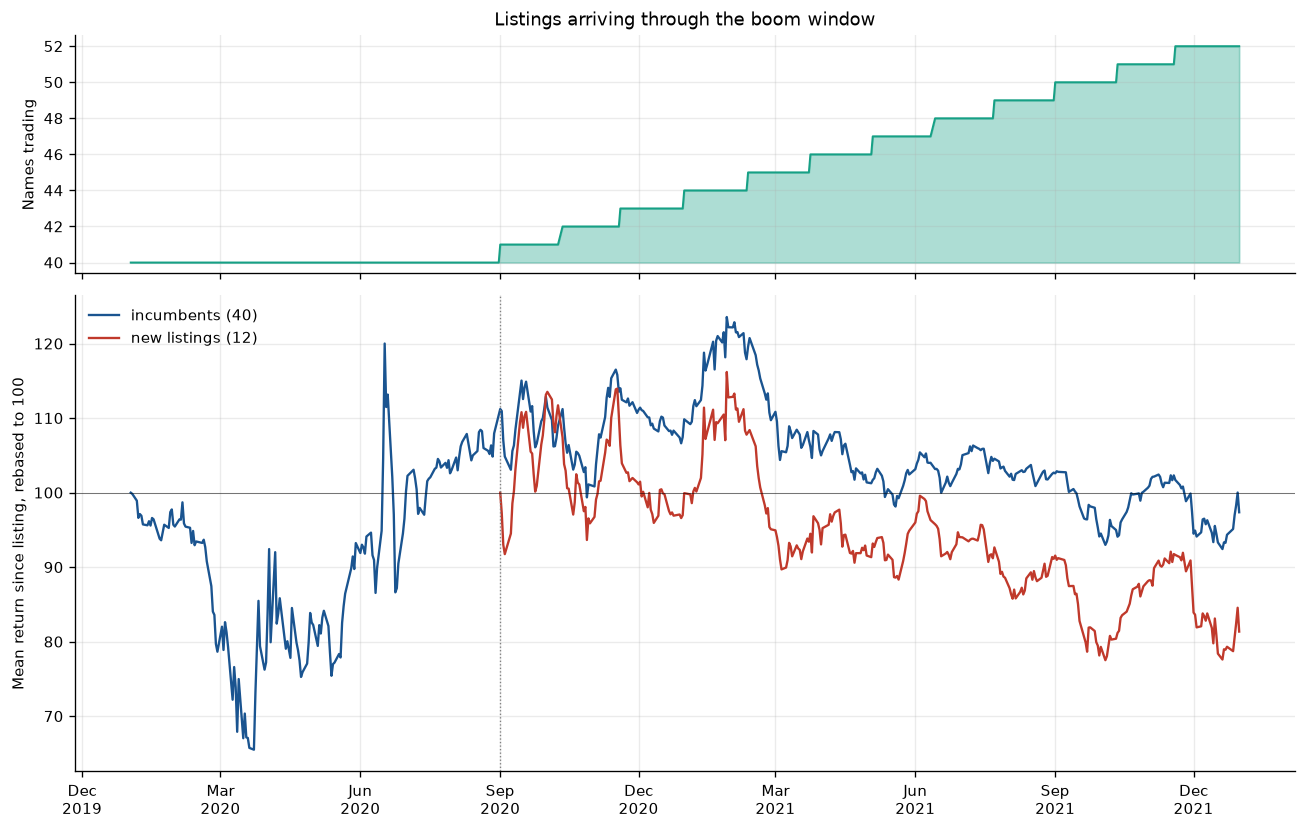

by 2021-12-31, mean return since listing:
  incumbents    -2.6%
  new listings  -18.6%


In [21]:
b3 = pa.table(engine3.bars(grain="day")).to_pylist()
by_day = {}
for r in b3:
    by_day.setdefault(r["day"], {})[r["instrument_id"]] = r["close"]
days_sorted = sorted(by_day)


def cohort_path(ids):
    out = []
    for d in days_sorted:
        vals = []
        for i in ids:
            start = listed_on.get(i, 0)
            if i in by_day[d] and start in by_day and i in by_day[start]:
                vals.append(by_day[d][i] / by_day[start][i])
        out.append(100 * st.mean(vals) if vals else None)
    return out


inc_ids, new_ids = list(range(INCUMBENTS)), list(listed_on)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [1, 2]})
xs = [DATES[d] for d in days_sorted]
count = [len(by_day[d]) for d in days_sorted]
ax1.fill_between(xs, count, INCUMBENTS, color="#16a085", alpha=0.35)
ax1.plot(xs, count, color="#16a085", lw=1.2)
ax1.set_ylabel("Names trading")
ax1.set_title("Listings arriving through the boom window", fontsize=11)

ax2.plot(xs, cohort_path(inc_ids), color="#1a5490", lw=1.4,
         label=f"incumbents ({len(inc_ids)})")
ax2.plot(xs, cohort_path(new_ids), color="#c0392b", lw=1.4,
         label=f"new listings ({len(new_ids)})")
ax2.axhline(100, color="black", lw=0.6, alpha=0.5)
ax2.axvline(BOOM_START, color="grey", lw=0.8, ls=":")
ax2.set_ylabel("Mean return since listing, rebased to 100")
ax2.legend(loc="upper left", frameon=False)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()

print(f"by {DATES[-1]}, mean return since listing:")
print(f"  incumbents    {cohort_path(inc_ids)[-1] - 100:+.1f}%")
print(f"  new listings  {cohort_path(new_ids)[-1] - 100:+.1f}%")

The new listings lag the incumbents, and they lag for a reason that was put
into the setup rather than discovered: they were floated at a 30% premium to
their own fundamentals, and reversion pulls a price back toward what the
company is worth. That is a mechanism reproducing an assumption rather than
evidence about real IPOs.

## One more lever: which sectors the universe is made of

2020 was not one market, it was twelve. The dispersion across sectors was the
year's real story, and an equal weighted index hides all of it:

| S&P 500 sector | 2020 total return |
|---|---|
| Information Technology | +43.9% |
| Consumer Discretionary | +33.3% |
| Materials | +20.7% |
| Health Care | +13.5% |
| Consumer Staples | +10.8% |
| Utilities | +0.5% |
| Financials | -1.7% |
| Real Estate | -2.2% |
| Energy | -33.7% |

pretium carries twelve sectors and they are not cosmetic. The cell below holds
fundamentals, seed and macro path completely fixed and varies nothing but the
sector label, so whatever separates the lines is the sector itself.

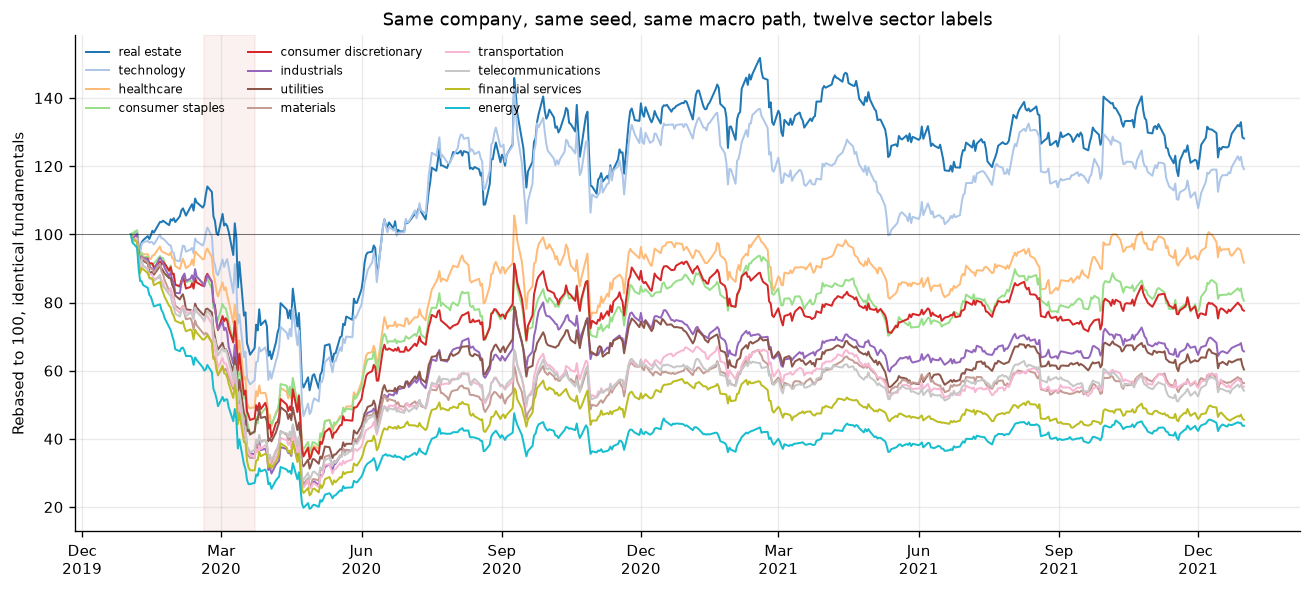

sector                       total return
------------------------------------------
real estate                       +28.2%
technology                        +19.2%
healthcare                         -8.3%
consumer staples                  -19.4%
consumer discretionary            -22.4%
industrials                       -34.3%
utilities                         -39.6%
materials                         -43.6%
transportation                    -44.7%
telecommunications                -45.9%
financial services                -54.3%
energy                            -56.1%

spread, best to worst: 84.3%


In [22]:
SECTORS = ["technology", "financial_services", "healthcare", "energy",
           "consumer_discretionary", "consumer_staples", "industrials",
           "materials", "real_estate", "utilities", "telecommunications",
           "transportation"]


def one_sector(sector):
    probe = pt.Instrument(
        "PROBE", sector, initial_price=100.0, shares_outstanding=1e9,
        eps=4.0, book_value_per_share=20.0, revenue_growth=0.05,
        avg_volume=5e6, beta=1.0, short_interest=1e6)
    u = pt.Universe([probe]); u.extend(pt.Universe.random(7, seed=44))
    e = pt.Engine(seed=2020, universe=u)
    for i in range(N):
        scen2.apply(e, i)
        e.run_days(1, first_day=i)
    return closes(e)


paths = {s: one_sector(s) for s in SECTORS}
finals = sorted(((p[-1] / p[0] - 1, s) for s, p in paths.items()), reverse=True)

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.get_cmap("tab20")
for n, (_, s) in enumerate(finals):
    p = paths[s]
    ax.plot(DATES, [100 * v / p[0] for v in p], lw=1.2, color=cmap(n / 12),
            label=s.replace("_", " "))
ax.axhline(100, color="black", lw=0.6, alpha=0.5)
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.set_ylabel("Rebased to 100, identical fundamentals")
ax.legend(loc="upper left", fontsize=7, ncol=3, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Same company, same seed, same macro path, twelve sector labels",
             fontsize=11)
fig.tight_layout()
plt.show()

print(f"{'sector':26s} {'total return':>14s}")
print("-" * 42)
for r, s in finals:
    print(f"{s.replace('_', ' '):26s} {r:>+13.1%}")
print()
print(f"spread, best to worst: {finals[0][0] - finals[-1][0]:.1%}")

Nothing varies but the label, and the spread is wide. Sector is doing real work
in this model.

The ends of the ranking are recognisable. Technology finishes near the top and
energy finishes last, the shape 2020 actually had. The middle of the ranking
does not correspond at all: real estate comes first here against roughly flat
in reality, and with twelve sectors and one seed the extremes agreeing is weak
evidence.

What the model is **not** doing is reproducing 2020. The ordering is its own
sector dynamics under this macro path. There is no field that makes energy fall
because oil went negative in April 2020, and nothing told the model that a
pandemic is good for software and bad for aircraft.

So this lever works through composition rather than instruction. If you want a
universe that behaves like 2020's market, you choose what the universe is made
of and accept the dynamics the model attaches to each sector. That is a
weaker claim than driving it, and worth knowing before building a study on top
of it.

## What to take from this

Four real macro series produced a crisis of roughly the right size on the wrong
dates. Sweeping the fields one at a time showed why: of the four, only
`qe_pe_boost` moves a valuation, and it had been pinned at zero through the
entire crash. Supplying the market's real valuation path moved the trough onto
the correct day and took the drawdown to within a fraction of a percent of
Apple's.

A scenario is only as good as the channel it reaches the model through. Adding
more real series does not help if they enter through fields that do not
connect, and sweeping them is how you find out which do.

### Which levers are worth pulling

Measured above, or measured the same way:

| lever | verdict |
|---|---|
| `qe_pe_boost` | the load bearing one. Linear, signed, and the only channel that bypasses the discount rate |
| `corporate_bond_yield` | the discount rate, and the sole route for everything upstream of it. The whole 2020 credit seizure is worth about 10% |
| `federal_funds_rate` | strong but conditional and slow. Unpinned it is worth about 11% at a 10% rate, arriving over thirty to sixty sessions. Pin the corporate bond yield and it is severed completely |
| `vix` | same story, much weaker. Reaches valuation only through the yield, and shapes volatility directly |
| `inflation_rate` | same story again. Pin the yield to something real, as here, and pinning inflation as well changes nothing at all |
| `fear_greed_index` | genuinely inert. Bit identical prices at every value from 0 to 100 out to 504 days, and no pricing code reads it |
| `gdp_growth`, `unemployment_rate` | reported in `macro_table` but not settable |
| `list_instrument`, `delist` | live, and used above |
| `sector` | large. Holding everything else fixed, the label alone spreads two year returns across a wide range |
| `short_interest` | close to inert. Taking it from zero to 200 million shares moves a 120 day price by about two hundredths of a percent, so a squeeze is not reachable this way |
| `run_days(volatility=...)` | live, a per run multiplier on how violently the session moves |

### What it still cannot do

*The company.* The two year total return remains far short of Apple's, and no
macro path will close it. Apple roughly tripled because revenue grew from
$260bn to $366bn; the model was handed the FY2019 accounts and never told what
came next. Macro explains the crisis, not the company.

*The starting valuation.* Apple's real FY2019 accounts put the model's
fundamental value about 24% above where the shares actually traded on 2 January
2020, so the run carries an upward reversion pull the real market did not have.
Rescaling the accounts to remove it was tried and makes the overall fit worse,
which is its own warning about tuning inputs to improve a score.

*Volatility, once the valuation path is supplied.* Realised volatility
overshoots Apple's by about a third, because a jumpy real index is now feeding
fair value as well as sentiment. Smoothing it away costs the timing that made
the repair worth making, so this one is a genuine trade rather than an
oversight.

*Independent validation, now.* Once the market valuation path is an input, the
simulated index tracking the real one is partly definitional. AAPL remains the
honest test, and even it inherits the market factor.

**And one caveat about the horizon.** The run is 505 days; pretium's envelope
is certified at 252, so a two year run is outside what the certification
covers. That is a judgement rather than a guarantee.

This notebook runs the DEFAULT preset, which is `pt-v10` since the 2026-08-26
era boundary. It holds all fourteen realism statistics in band at one year and
twelve of fourteen at two. Earlier versions of this notebook pinned `pt-v6`,
which no longer holds the most statistics of anything on offer.

*The default is not the best preset for this particular path.* Everything
above, re-run under four presets, changing nothing but the name:

| | pt-v3 | pt-v6 | pt-v9 | pt-v10 | actual |
|---|---|---|---|---|---|
| realised vol against the VIX input | +0.736 | +0.741 | +0.706 | +0.706 | |
| AAPL level correlation | +0.813 | +0.784 | +0.718 | +0.718 | |
| AAPL daily return correlation | +0.450 | +0.439 | +0.369 | +0.366 | |
| index against the S&P, daily | +0.661 | +0.660 | +0.549 | +0.546 | |
| annualised volatility | 47.3% | 49.5% | 53.8% | 53.9% | 37.4% |
| maximum drawdown | -33.3% | -31.5% | -34.3% | -34.6% | -31.4% |
| date of the trough | 2020-03-12 | 2020-03-23 | 2020-10-27 | 2020-10-27 | 2020-03-23 |

pt-v6 fits this path better on every row. That is worth understanding rather
than explaining away, and it is mostly about what a single name can show.

The trough date is a seed artefact. Across four engine seeds the default puts
the trough on 2020-10-27, 2020-04-01, 2020-04-13 and 2020-04-03; only the seed
this notebook uses lands in October, and pt-v6 on the same four seeds gives
03-23, 04-01, 03-23 and 04-03. The drawdown difference is not an artefact: the
default runs deeper on all four seeds (-34.6, -61.7, -55.3, -48.8 against
-31.5, -60.7, -50.9, -40.5), because its market reacts to its own moves and
this path hands it a violent year.

The correlations are a genuine trade. The default was calibrated on a
cross-section of forty names measured against real-market bands, and it wins
there: fourteen statistics in band against pt-v6's eleven of thirteen on the
old panel. This notebook measures one real company against thirty-nine
generated ones, which is not what that calibration optimises. If your study is
a single name against a real path, `model="pt-v6"` is defensible and you can
say why. If it is anything cross-sectional, the default is the better market.

The transient penalty does not bite here. `scenario_response.py` measures the
reaction to a twenty-day spike; this notebook supplies the VIX every day for
505 days. Tracking a path and reacting to a shock are different jobs, which is
how two presets 11 points apart on that instrument land within 0.005 of each
other on the first row of this table.

### Where to go next

- `04-how-realistic-is-this.ipynb` for what the envelope certifies and what it
  admits it does not.
- `03-why-did-the-price-move.ipynb` for the attribution machinery used above.
- `docs/scenario-recipes.md` for the scenario surface, including the compound
  episode this notebook grew out of.